<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Final_NN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core libraries
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import BorderlineSMOTE
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import AUC, Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import os, random, numpy as np, tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [3]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [4]:
# Copy data
churn_data = df.copy()

In [5]:
churn_data.columns

Index(['TotalCharges_numeric', 'tenure', 'MonthlyCharges', 'SeniorCitizen',
       'AvgChargePerMonth', 'Churn', 'Dependents_Yes',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes'],
      dtype='object')

In [6]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)

churn_data.head()

,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Churn,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,0.072892,0.013889,0.115423,0,0.090838,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0.749358,0.472222,0.385075,0,0.342582,0,0,0,1,0,0,0,1,0,0,1,0,0
2,0.280590,0.027778,0.354229,0,0.262376,1,0,0,1,0,1,0,0,0,0,0,0,1
3,0.745063,0.625000,0.239303,0,0.283037,0,0,0,1,0,0,0,1,0,1,1,0,0
4,0.335724,0.027778,0.521891,0,0.329474,1,0,0,0,0,0,0,0,0,0,0,0,1


In [8]:
# INITIATE X AND Y
X = churn_data.drop(columns=['Churn'])
y = churn_data['Churn']

# Randomly select 10 samples for inference
X_infer = X.sample(n=10, random_state=42)
y_infer = y.loc[X_infer.index]

# Remove inference rows from main dataset
X_rest = X.drop(X_infer.index)
y_rest = y.drop(y_infer.index)

# Split the rest into training+validation and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.2,
    random_state=42,
    stratify=y_rest
)
# Further split training set into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

# Check shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_infer:", X_infer.shape)

# Check class distribution in original training set
print("Original training set class distribution:")
print(y_train.value_counts())

# Percentages
print("\nOriginal training set class distribution (percentages):")
print(y_train.value_counts(normalize=True) * 100)

X_train: (4500, 17)
X_val: (1126, 17)
X_test: (1407, 17)
X_infer: (10, 17)
Original training set class distribution:
Churn
0    3307
1    1193
Name: count, dtype: int64

Original training set class distribution (percentages):
Churn
0    73.488889
1    26.511111
Name: proportion, dtype: float64


Class weights (before SMOTE): {np.int64(0): np.float64(0.680374962201391), np.int64(1): np.float64(1.8860016764459346)}
Updated Class weights: {0: np.float64(0.8164499546416693), 1: np.float64(1.8860016764459346)}
After Borderline-SMOTE class counts:
 Churn
0    3307
1    3307
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5003 - auc: 0.5517 - f1_score: 0.4274 - loss: 0.8067 - precision: 0.3511 - recall: 0.6885 - val_accuracy: 0.2647 - val_auc: 0.5532 - val_f1_score: 0.4146 - val_loss: 1.6562 - val_precision: 0.2647 - val_recall: 1.0000
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4500 - auc: 0.6349 - f1_score: 0.4929 - loss: 0.9649 - precision: 0.3576 - recall: 0.9354 - val_accuracy: 0.3375 - val_auc: 0.6998 - val_f1_score: 0.4425 - val_loss: 1.3960 - val_precision: 0.2850 - val_recall: 0.9966
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5073 - auc: 0.7145 - f1_score: 0.5173 - loss: 0.8697 - precision: 0.3835 - recall: 0.9313 - val_accuracy: 0.3837 - val_auc: 0.7514 - val_f1_score: 0.4591 - val_loss: 1.2925 - val_precision: 0.3000 - val_recall: 0.9966
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5503 - auc: 0.7489 - f1_score: 0.5343 - loss: 0.8298 - precision: 0.4034 - re

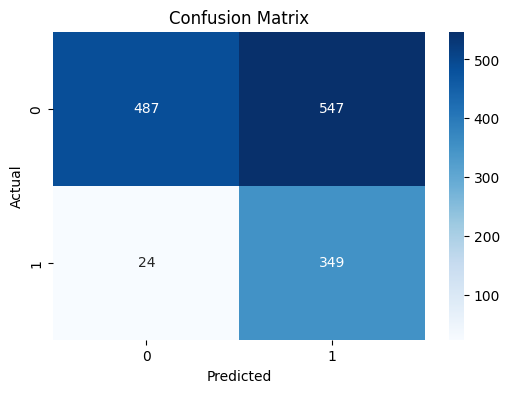

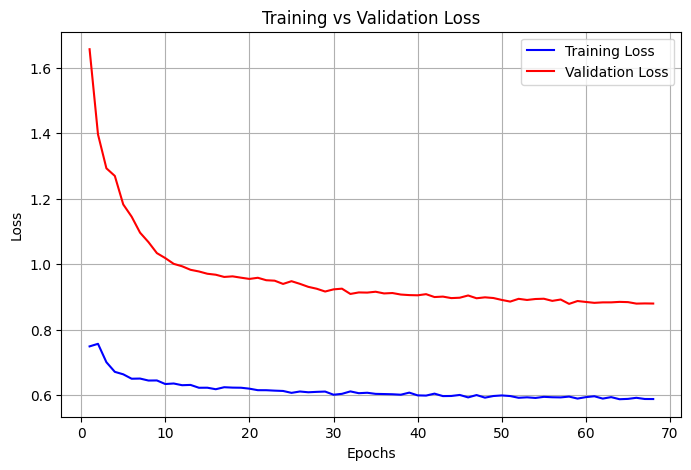

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Compute class weights based on original training set (before SMOTE)
classes = np.unique(y_train)
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights (before SMOTE):", class_weight_dict)

# Give slightly more weight to class 0 if needed
class_weight_dict = {0: class_weights_values[0]*1.2, 1: class_weights_values[1]}
print("Updated Class weights:", class_weight_dict)

# Apply Borderline-SMOTE on training set only
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_res).value_counts())

# Initialize the model
model = tf.keras.Sequential()

# Input layer + first hidden layer
model.add(tf.keras.layers.Dense(
    units=32,
    activation='relu',
    input_shape=(X_train_res.shape[1],),
))
model.add(Dropout(0.2, seed=SEED))

# Second hidden layer
model.add(tf.keras.layers.Dense(
    units=16,
    activation='relu'
))
model.add(Dropout(0.2, seed=SEED))

# Output layer
model.add(tf.keras.layers.Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

    # Create optimizer
opt = Adam(learning_rate=0.0005)

# Compile model
model.compile(
    optimizer= opt,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

y_train_pred = (model.predict(X_train_res) > 0.6).astype(int)
y_val_pred = (model.predict(X_val) > 0.6).astype(int)
y_test_pred = (model.predict(X_test) > 0.6).astype(int)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Classification report for training set
print("Classification Report - Training Set")
print(classification_report(y_train_res, y_train_pred))

# Classification report for validation set
print("Classification Report - Validation Set")
print(classification_report(y_val, y_val_pred))

# Classification report for test set
print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

import matplotlib.pyplot as plt

# Epochs
epochs = range(1, len(history.history['loss']) + 1)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, history.history['loss'], 'b-', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()